# Logistic Regression - Fraud Detection

In [1]:
# Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

In [2]:
# Part 1: Load the data

# Main files
df_cards = pd.read_csv("data/cards_data.csv")
df_users = pd.read_csv("data/users_data.csv")
df_transactions = pd.read_csv("data/transactions_data.csv")

# load the merchant category codes
with open("data/mcc_codes.json") as file:
    mcc_codes = json.load(file)

# Load the fraud labels
with open("data/train_fraud_labels.json") as file:
    labels = json.load(file)["target"]  # extract the nested dict

# Merge the transactions dataset with the fraud labels
labels_df = pd.Series(labels, name = "fraud_label").reset_index()
labels_df.columns = ["id", "fraud_label"]
labels_df["id"] = labels_df["id"].astype(int)

df = df_transactions.merge(labels_df, on = "id")
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,fraud_label
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,No
3,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,No
4,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN,No


In [3]:
# Part 2: EDA

# General Info and Shape of the dataset
print(df.dtypes)
print()
print(df.isnull().sum())
print()
print(df.shape)

id                  int64
date                  str
client_id           int64
card_id             int64
amount                str
use_chip              str
merchant_id         int64
merchant_city         str
merchant_state        str
zip               float64
mcc                 int64
errors                str
fraud_label           str
dtype: object

id                      0
date                    0
client_id               0
card_id                 0
amount                  0
use_chip                0
merchant_id             0
merchant_city           0
merchant_state    1047865
zip               1107377
mcc                     0
errors            8773196
fraud_label             0
dtype: int64

(8914963, 13)


fraud_label
No     8901631
Yes      13332
Name: count, dtype: int64


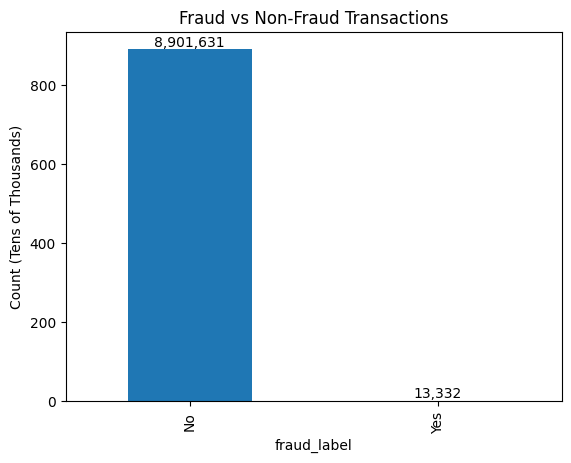

In [4]:
# Plot the class distribution
print(df["fraud_label"].value_counts())
fraud_counts = df["fraud_label"].value_counts()

ax = fraud_counts.plot(kind = "bar")
ax.set_title("Fraud vs Non-Fraud Transactions")
ax.set_ylabel("Count (Tens of Thousands)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x / 10000)}"))

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "bottom")

plt.show()

In [5]:
# Create a table for the transaction amount distribution
df["amount_range"] = df["amount"].str.replace("$", "", regex = False).astype(float)

bins = [-np.inf, 0, 10, 25, 50, 100, 250, 500, 1000, 2000, 5000, np.inf]
labels = ["<$0", "$0-10", "$10-25", "$25-50", "$50-100", "$100-250",
          "$250-500", "$500-1000", "$1000-2000", "$2000-5000", "$5000+"]

amount_table = pd.cut(df["amount_range"], bins = bins, labels = labels).value_counts().sort_index()
amount_table = amount_table.rename("Count").to_frame()
amount_table["%"] = (amount_table["Count"] / len(df) * 100).round(2)
amount_table

,Count,%
amount_range,,
<$0,449972,5.05
$0-10,1947741,21.85
$10-25,1735234,19.46
$25-50,1802739,20.22
$50-100,2021073,22.67
$100-250,821487,9.21
$250-500,107855,1.21
$500-1000,22733,0.25
$1000-2000,5905,0.07


In [6]:
# Create a table for the transaction amount distribution grouped by fraud label
fraud_amount_table = (
    df.groupby(pd.cut(df["amount_range"], bins = bins, labels = labels))["fraud_label"]
    .value_counts()
    .unstack(fill_value = 0)
    .rename(columns={"Yes": "fraud_count", "No": "non_fraud_count"})
)

fraud_amount_table["total"] = fraud_amount_table["fraud_count"] + fraud_amount_table["non_fraud_count"]
fraud_amount_table["fraud_rate(%)"] = (
    fraud_amount_table["fraud_count"] / fraud_amount_table["total"] * 100
).round(3)

fraud_amount_table

fraud_label,non_fraud_count,fraud_count,total,fraud_rate(%)
amount_range,,,,
<$0,449477,495,449972,0.110
$0-10,1945616,2125,1947741,0.109
$10-25,1734023,1211,1735234,0.070
$25-50,1801137,1602,1802739,0.089
$50-100,2018255,2818,2021073,0.139
$100-250,817973,3514,821487,0.428
$250-500,106641,1214,107855,1.126
$500-1000,22480,253,22733,1.113
$1000-2000,5832,73,5905,1.236


In [7]:
# log-transform amount to handle skew + non-linear fraud relationship
# (reason: fraud rate table above shows fraud rate rises sharply above ~$250,
# raw amount is heavily right-skewed — log-transform compresses the tail before scaling)
df["amount_log"] = np.sign(df["amount_range"]) * np.log1p(np.abs(df["amount_range"]))